## The Scale Paradox: Airport Volume vs Delay
Jointplot with LOWESS trend and busiest-airport highlighting to test if delay scales linearly with traffic or plateaus.

In [14]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')

# Load merged dataset
possible_paths = ['../data/processed/merged_data.csv', 'data/processed/merged_data.csv', 'merged_data.csv']
df = None
for path in possible_paths:
    try:
        df = pd.read_csv(path, low_memory=False)
        print(f'Loaded dataset from: {path}')
        break
    except FileNotFoundError:
        continue

if df is None:
    raise FileNotFoundError('merged_data.csv not found in project root or data/processed/')

required = {'ORIGIN_AIRPORT', 'DEPARTURE_DELAY'}
missing = required - set(df.columns)
if missing:
    raise ValueError(f'Missing required columns: {missing}')

# Airport-level summary
airport_stats = (
    df.groupby('ORIGIN_AIRPORT', as_index=False)
      .agg(
          flight_count=('ORIGIN_AIRPORT', 'size'),
          mean_departure_delay=('DEPARTURE_DELAY', 'mean')
      )
      .dropna(subset=['mean_departure_delay'])
)

top10 = airport_stats.nlargest(10, 'flight_count').copy()
top10_codes = set(top10['ORIGIN_AIRPORT'])

airport_stats.head()

Loaded dataset from: ../data/processed/merged_data.csv


,ORIGIN_AIRPORT,flight_count,mean_departure_delay
0,10135,239,7.324561
1,10136,194,2.301136
2,10140,1758,5.599880
3,10141,67,1.532258
4,10146,84,5.294872


statsmodels not installed: using polynomial trend fallback instead of LOWESS.


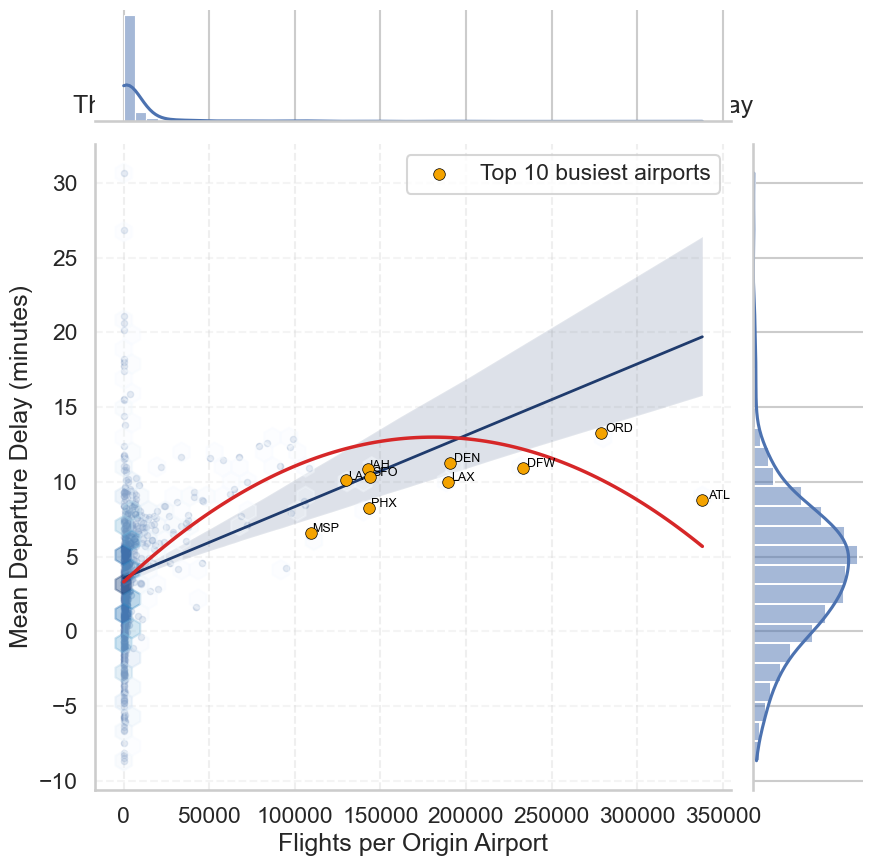

In [15]:
# Jointplot with regression + LOWESS smoother
import importlib.util

g = sns.jointplot(
    data=airport_stats,
    x='flight_count',
    y='mean_departure_delay',
    kind='reg',
    height=9,
    scatter_kws={'alpha': 0.22, 's': 20, 'color': '#5B7DB1'},
    line_kws={'color': '#1F3B6D', 'linewidth': 2}
)

# Overlay density to handle clumping among small airports
g.ax_joint.hexbin(
    airport_stats['flight_count'],
    airport_stats['mean_departure_delay'],
    gridsize=35,
    cmap='Blues',
    mincnt=1,
    alpha=0.35
)

# Add LOWESS curve to inspect non-linearity (efficiency curve)
if importlib.util.find_spec('statsmodels') is not None:
    sns.regplot(
        data=airport_stats,
        x='flight_count',
        y='mean_departure_delay',
        lowess=True,
        scatter=False,
        line_kws={'color': '#D62728', 'linewidth': 2.5, 'label': 'LOWESS'},
        ax=g.ax_joint
    )
else:
    # Fallback if statsmodels is unavailable
    sns.regplot(
        data=airport_stats,
        x='flight_count',
        y='mean_departure_delay',
        order=2,
        scatter=False,
        ci=None,
        line_kws={'color': '#D62728', 'linewidth': 2.5, 'label': 'Polynomial trend (LOWESS fallback)'},
        ax=g.ax_joint
    )
    print('statsmodels not installed: using polynomial trend fallback instead of LOWESS.')

# Highlight and label top 10 busiest airports
top10_plot = airport_stats[airport_stats['ORIGIN_AIRPORT'].isin(top10_codes)]
g.ax_joint.scatter(
    top10_plot['flight_count'],
    top10_plot['mean_departure_delay'],
    s=70,
    color='#F4A300',
    edgecolor='black',
    linewidth=0.5,
    zorder=5,
    label='Top 10 busiest airports'
)

for _, row in top10_plot.iterrows():
    g.ax_joint.text(
        row['flight_count'] * 1.01,
        row['mean_departure_delay'] + 0.03,
        str(row['ORIGIN_AIRPORT']),
        fontsize=9,
        color='black'
    )

g.ax_joint.set_title('The Scale Paradox: Airport Volume vs Mean Departure Delay', pad=22)
g.ax_joint.set_xlabel('Flights per Origin Airport')
g.ax_joint.set_ylabel('Mean Departure Delay (minutes)')
g.ax_joint.grid(axis='x', linestyle='--', alpha=0.3)
g.ax_joint.grid(axis='y', linestyle='--', alpha=0.2)
g.ax_joint.legend(loc='best')
plt.show()

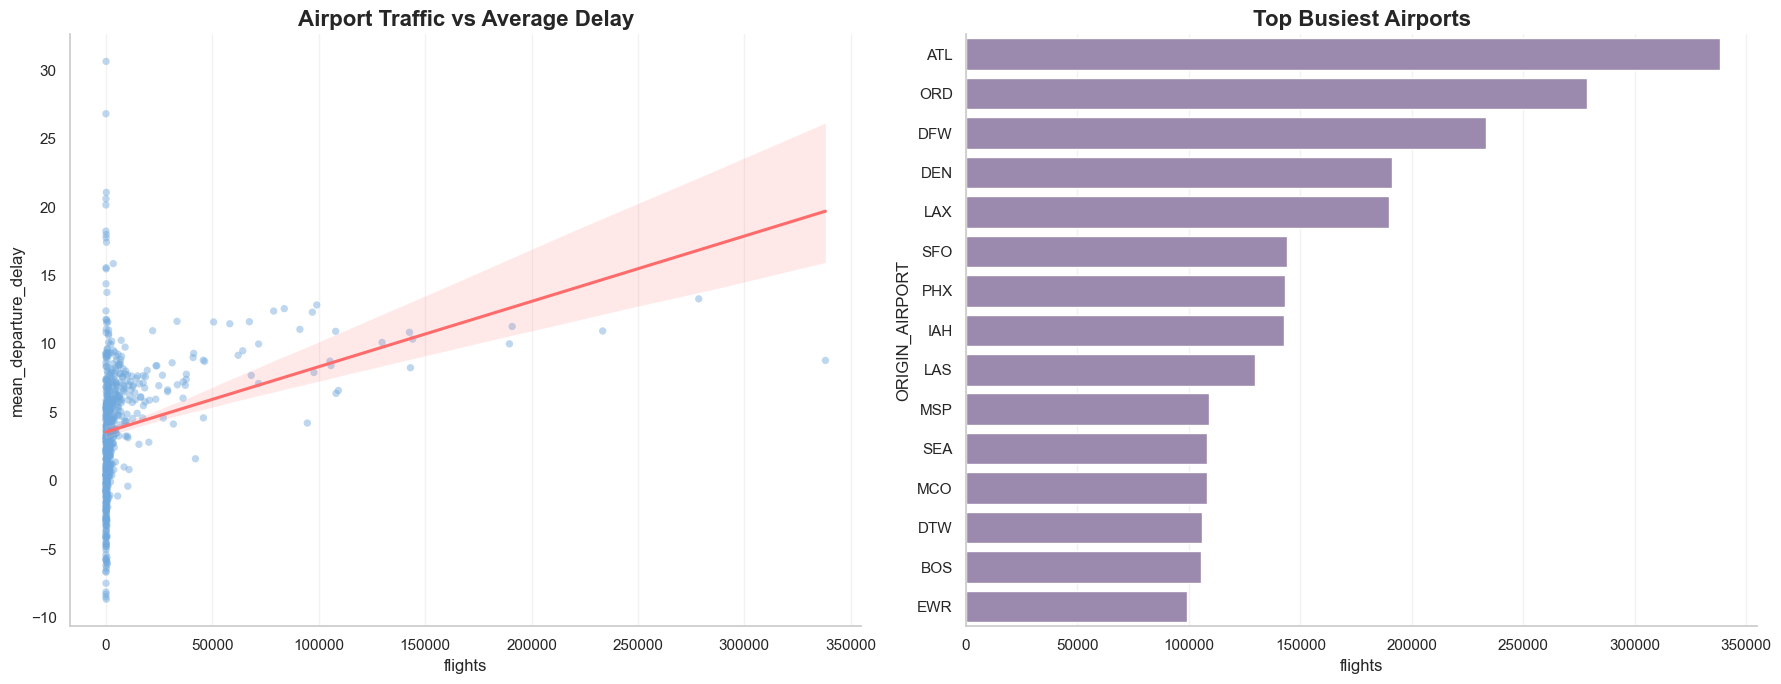

,ORIGIN_AIRPORT,flight_count,mean_departure_delay
0,ATL,338087,8.799828
1,ORD,278573,13.300433
2,DFW,233439,10.954331
3,DEN,190884,11.281074
4,LAX,189622,10.013069
5,SFO,144147,10.355391
6,PHX,143115,8.262444
7,IAH,142655,10.856773
8,LAS,129783,10.115110
9,MSP,109235,6.604334


In [16]:
# Airport Traffic vs Delay + Horizontal Top-Busiest chart (matching requested style)
sns.set_theme(style='whitegrid', context='notebook')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left panel: scatter + regression
sns.regplot(
    data=airport_stats,
    x='flight_count',
    y='mean_departure_delay',
    scatter_kws={'alpha': 0.45, 's': 28, 'color': '#6FA8DC', 'edgecolor': 'none'},
    line_kws={'color': '#FF6B6B', 'linewidth': 2.2},
    ax=axes[0]
)
axes[0].set_title('Airport Traffic vs Average Delay', fontsize=16, weight='bold')
axes[0].set_xlabel('flights')
axes[0].set_ylabel('mean_departure_delay')

# Right panel: horizontal bar chart for busiest airports
top_busiest = (
    airport_stats.sort_values('flight_count', ascending=False)
               .head(15)
               .sort_values('flight_count', ascending=False)
)

sns.barplot(
    data=top_busiest,
    x='flight_count',
    y='ORIGIN_AIRPORT',
    color='#9B84B3',
    ax=axes[1]
)
axes[1].set_title('Top Busiest Airports', fontsize=16, weight='bold')
axes[1].set_xlabel('flights')
axes[1].set_ylabel('ORIGIN_AIRPORT')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', linestyle='-', alpha=0.25)
    ax.grid(axis='y', visible=False)

plt.tight_layout()
plt.show()

# Quick table for reference
top_busiest.sort_values('flight_count', ascending=False).reset_index(drop=True)



#### The airport scale analysis explores whether busier airports experience worse delays due to higher traffic volume. The scatter plot shows a positive relationship between the number of flights and average departure delay, suggesting that airports handling larger volumes tend to experience slightly higher delays, likely due to congestion and operational complexity. However, the spread of points also indicates that many large airports still maintain relatively controlled delay levels, implying that major hubs have systems and infrastructure to manage high traffic efficiently. The busiest airports such as ATL, ORD, and DFW dominate in total flight volume, yet their delays do not increase proportionally with traffic. This suggests that while scale introduces operational pressure, well-managed large hubs can handle high demand without dramatically worsening delays, meaning travelers may not necessarily need to avoid major airports despite their heavy traffic. ✈️